# 2-D Random Walker

Text(0, 0.5, 'Distance')

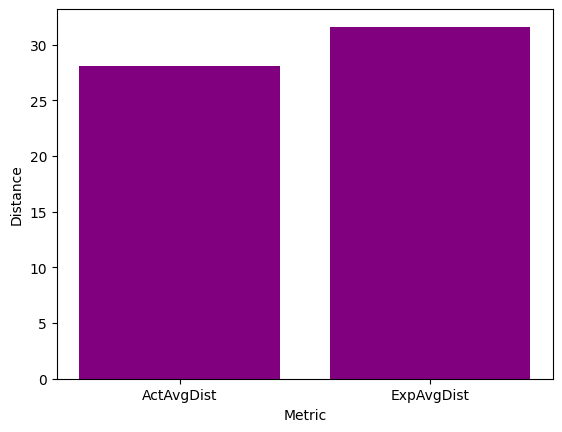

In [4]:
#from vpython import *
import random
import matplotlib.pyplot as plt
import numpy as np
import math
#scene = canvas()

#scene.autoscale = True

#ball = sphere(pos=vec(0, 0, 0), radius=0.001, color=color.blue, make_trail = True) 
#velocity = vec(0, 0, 0)

# dt = 0.01
# t = 0
RandVar = 0

# down = 0
# up = 0
# left = 0
# right = 0
numRuns = 0
CurDist = 0
N = 1000

while numRuns < 100:
    x,y = 0,0 #origin
    steps = 0
    while steps < N:
        
        # rate(10)
        RandVar = random.randint(1,4)
        if RandVar == 1:
            # velocity = vec(0,-1,0) #down
            # down = down + 1
            y -= 1
        elif RandVar == 2:
            # velocity = vec(0,1,0)  #up
            # up = up + 1
            y += 1
        elif RandVar == 3:
            # velocity = vec(-1,0,0) #left
            # left = left + 1 
            x -= 1
        else:
            # velocity = vec(1,0,0) #right
            # right = right + 1 
            x += 1
        steps = steps + 1
        # ball.pos = ball.pos + velocity * dt
        # t = t + dt
    CurDist += math.hypot(x, y)
    numRuns = 1 + numRuns 
AvgDist = CurDist/numRuns 
ExpAvgDist = math.sqrt(N)

categories = np.array(["ActAvgDist", "ExpAvgDist"])
values = np.array([AvgDist,ExpAvgDist])

plt.bar(categories, values, color="purple")

plt.xlabel("Metric")
plt.ylabel("Distance")
    

# categories = np.array(["Down", "Up", "Left", "Right"])
# values = np.array([down,up,left,right])

# plt.bar(categories, values, color="green")

# plt.xlabel("Direction")
# plt.ylabel("Steps")
        
    


b. 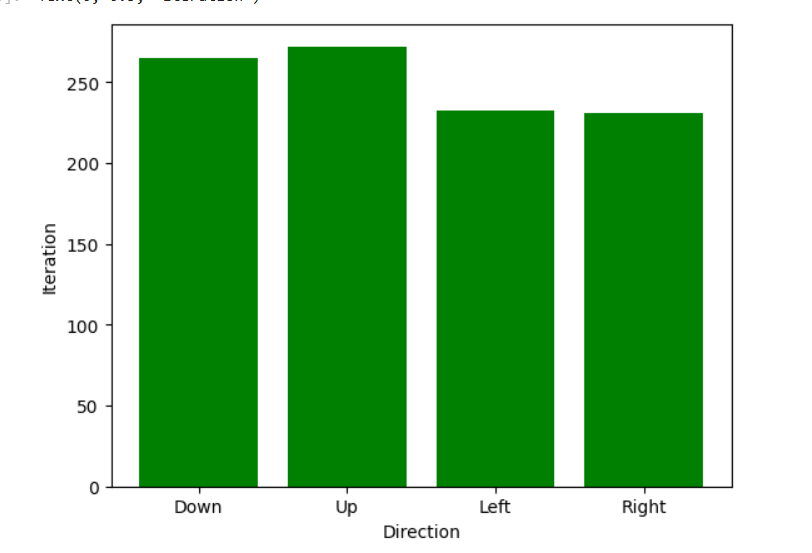 
From the Plot you can tell that each direction was passed through at roughly the same number of iterations which was around 250 give or take from 1000 iterations.

c. 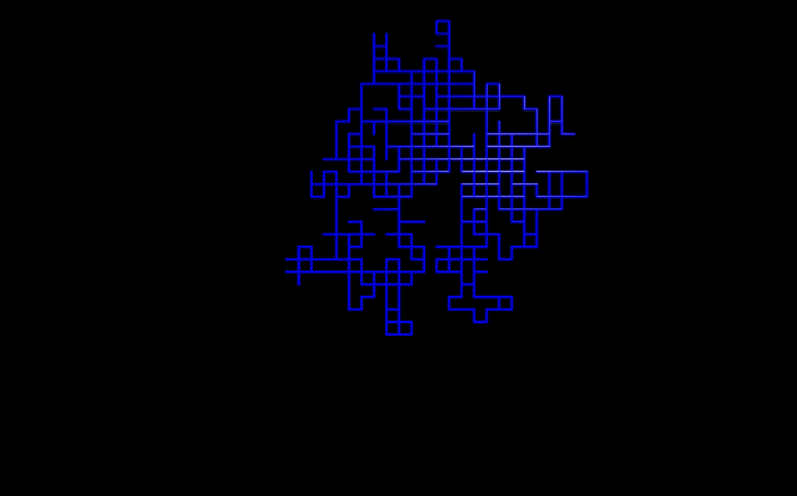
From this you can see the structure looks lik an incomplete grid, evenly spaced at each point, rotating it would have no 3rd dimension so it is a 2d grid.

d. 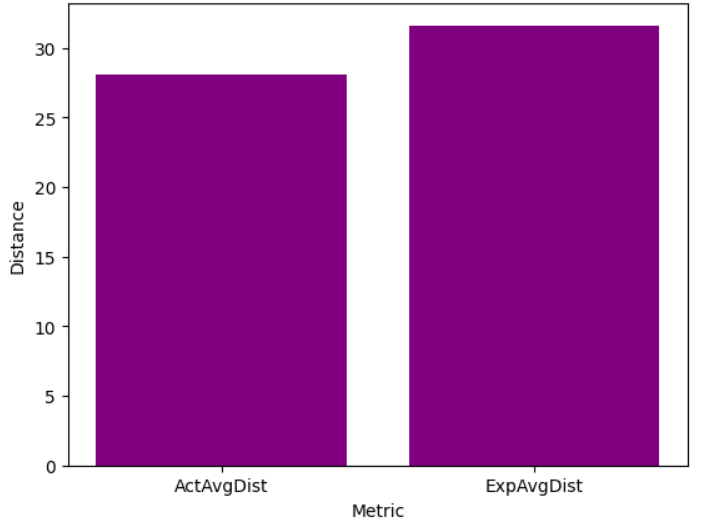
I took the averages of 100 runs of 1000 step iterations and it would seem the actual distance traveled is typically shorter than the Expected



# 2-state 1-D cellular automaton


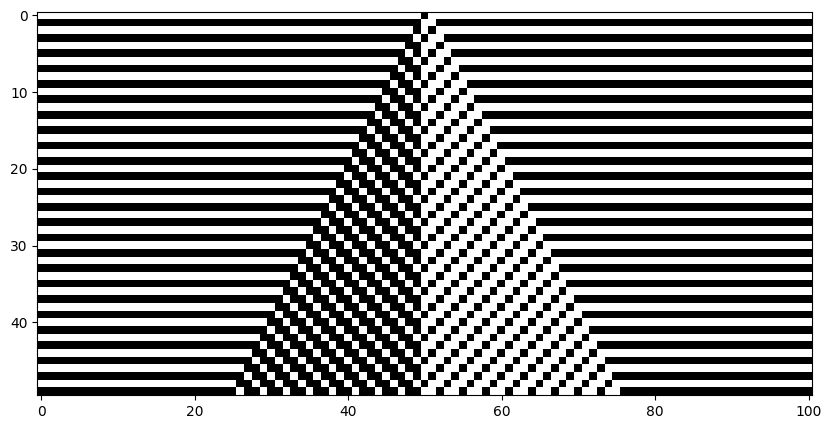

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import math


def getRule(ruleNum): #convert rule to new binary pattern
    ruleBinary = format(ruleNum, '08b')
    ruleNew = {}
    patterns = [(1,1,1),(1,1,0),(1,0,1),(1,0,0),(0,1,1),(0,1,0),(0,0,1),(0,0,0)]
    for i, pattern in enumerate(patterns):
        ruleNew[pattern] = int(ruleBinary[i]) #New pattern converted
    return ruleNew

def getGrid(ruleNum, num_cells=101, num_steps=50): #run the algorithm to get grid pattern
    rule = getRule(ruleNum)
    grid = np.zeros((num_steps, num_cells), dtype=int)
    grid[0, num_cells // 2] = 1 #set center cell alive
    for t in range(1, num_steps):
        for i in range(num_cells):
            left   = grid[t-1, (i-1) % num_cells]  
            center = grid[t-1, i]
            right  = grid[t-1, (i+1) % num_cells]
            grid[t, i] = rule[(left, center, right)]
    
    return grid

grid = getGrid(ruleNum = 99)
plt.figure(figsize=(10, 6))
plt.imshow(grid, cmap='binary', interpolation='nearest')

    

a. I Choose Rule 222 because the pattern it produces looks cool and it is one of the patterns that gives its rules avaliable on the Wolfrom MathWorld site, I also did 99 because the design looked cool

b. 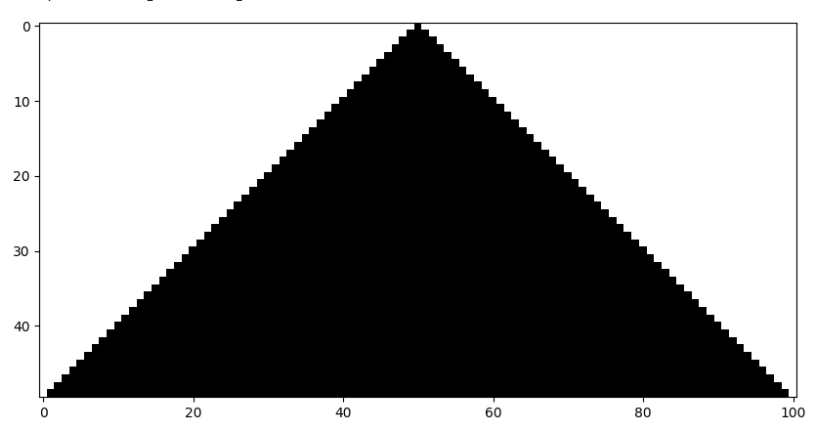 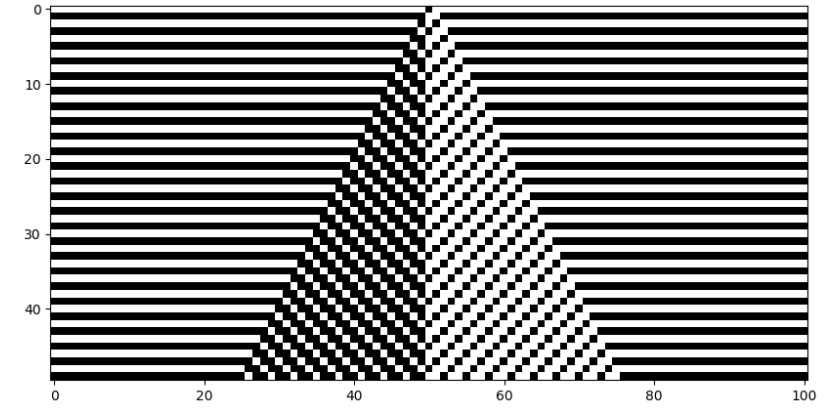 First image is 222, second is 99

c. I ran 50 time steps because the pattern looks visibly clear and doesn't hit any boundaries, I could do more if I wanted to get more interesting patterns, from the Grid

# Conway's Game of Life

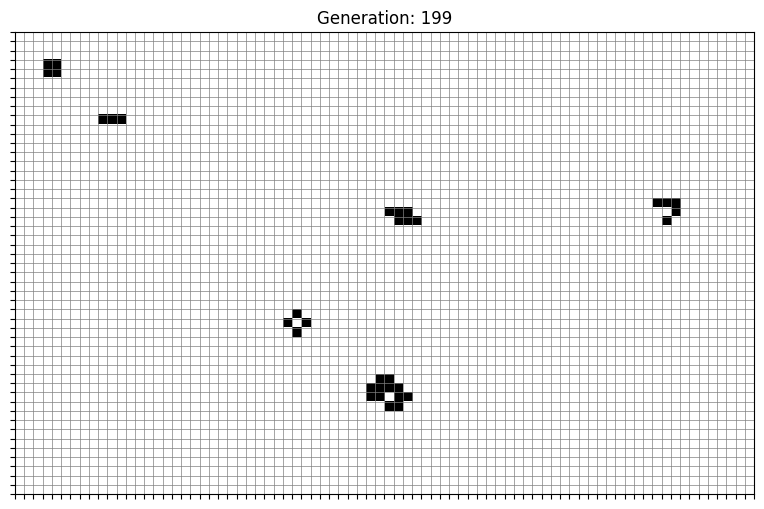

In [1]:
#Any live cell with fewer than two live neighbours dies, as if by underpopulation.
#Any live cell with two or three live neighbours lives on to the next generation.
#Any live cell with more than three live neighbours dies, as if by overpopulation.
#Any dead cell with exactly three live neighbours becomes a live cell, as if by reproduction.

import matplotlib.pyplot as plt
import numpy as np
import math
import random

rows = 50
cols = 80


def getRandGrid(row, col): #Get random grid assignment
    grid = np.zeros((row, col), dtype=int)
    for i in range(row):
        for j in range(col):
            grid[i][j] = random.randint(0, 1)
    return grid

def getGridPeriod(row, col):
    grid = np.zeros((row, col), dtype=int)
    grid[3][3] = 1 #Block
    grid[3][4] = 1
    grid[4][3] = 1
    grid[4][4] = 1
    
    grid[9][9] = 1 #blinker
    grid[9][10] = 1
    grid[9][11] = 1
    
    grid[20][20] = 1 #Glider
    grid[19][21] = 1
    grid[18][21] = 1
    grid[18][20] = 1
    grid[18][19] = 1

    grid[30][30] = 1#tub
    grid[31][31] = 1
    grid[31][29] = 1
    grid[32][30] = 1

    grid[20][41] = 1 # Toad
    grid[20][42] = 1
    grid[20][43] = 1
    grid[19][40] = 1
    grid[19][41] = 1
    grid[19][42] = 1

    grid[40][20] = 1 #lightweight spaceship
    grid[40][21] = 1
    grid[39][18] = 1
    grid[39][19] = 1
    grid[39][21] = 1
    grid[39][22] = 1
    grid[38][18] = 1
    grid[38][19] = 1
    grid[38][20] = 1
    grid[38][21] = 1
    grid[37][19] = 1
    grid[37][20] = 1
    return grid
    


def countLiveNeighbor(grid, row, col): #gets number of neighbors for specified point
    total = 0
    for i in [-1,0,1]:
        for j in [-1,0,1]:
            if i == 0 and j == 0: 
                continue
            r = (row + i) % rows
            c = (col + j) % cols
            total += grid[r][c]
    return total

def newGen(grid):
    newGrid = np.zeros((rows, cols), dtype=int)
    for i in range(rows):
        for j in range(cols):
            N = countLiveNeighbor(grid, i, j) # count number of neighbors w/ func
            if grid[i][j] == 1:
                if N == 2 or N == 3: #death from overpopulation and underpopulation Anything not 2 or 3
                    newGrid[i][j] = 1
                else:
                    newGrid[i][j] = 0
            else:
                if N == 3:
                    newGrid[i][j] = 1
                else:
                    newGrid[i][j] = 0
    return newGrid

from IPython.display import display, clear_output

grid = getGridPeriod(rows, cols) #change if want to change to random assignment or test periods
fig, ax = plt.subplots(figsize=(10, 6))

for generation in range(200):
    grid = newGen(grid)
    ax.clear()
    ax.imshow(grid, cmap='binary', interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, cols, 1), [])
    ax.set_yticks(np.arange(-0.5, rows, 1), [])
    ax.grid(color='grey', linewidth=0.5)
    ax.set_title(f'Generation: {generation}')
    clear_output(wait=True)  # clears the old plot
    display(fig)             # shows the new one
    plt.pause(0.1)

c. The implementation works testing with 2 still lifes, 2 oscillators, and 2 spaceships. I can confirm the 2 still lifes don't change and stay same position, the oscillators stay in the same spots but alternates between shapes. Spaceships keep their form but move throughtout the gridspace, if they move off screen they come back from the other side of the grid. Running the program with the set period grid will show these.

# Conway's Game of Life Asynchronous 

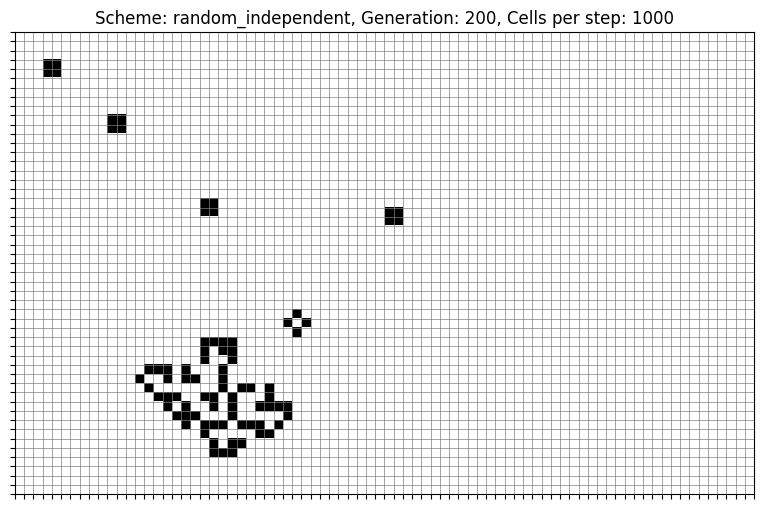

In [3]:
##### Any live cell with fewer than two live neighbours dies, as if by underpopulation.
#Any live cell with two or three live neighbours lives on to the next generation.
#Any live cell with more than three live neighbours dies, as if by overpopulation.
#Any dead cell with exactly three live neighbours becomes a live cell, as if by reproduction.

import matplotlib.pyplot as plt
import numpy as np
import math
import random
from IPython.display import display, clear_output

rows = 50
cols = 80
cells_per_step = 1000 #how many cells to change at a time
UPDATE_SCHEME = 'random_independent'


def getRandGrid(row, col): #Get random grid assignment
    grid = np.zeros((row, col), dtype=int)
    for i in range(row):
        for j in range(col):
            grid[i][j] = random.randint(0, 1)
    return grid

def getGridPeriod(row, col):
    grid = np.zeros((row, col), dtype=int)
    grid[3][3] = 1 #Block
    grid[3][4] = 1
    grid[4][3] = 1
    grid[4][4] = 1
    
    grid[9][9] = 1 #blinker
    grid[9][10] = 1
    grid[9][11] = 1
    
    grid[20][20] = 1 #Glider
    grid[19][21] = 1
    grid[18][21] = 1
    grid[18][20] = 1
    grid[18][19] = 1

    grid[30][30] = 1#tub
    grid[31][31] = 1
    grid[31][29] = 1
    grid[32][30] = 1

    grid[20][41] = 1 # Toad
    grid[20][42] = 1
    grid[20][43] = 1
    grid[19][40] = 1
    grid[19][41] = 1
    grid[19][42] = 1

    grid[40][20] = 1 #lightweight spaceship
    grid[40][21] = 1
    grid[39][18] = 1
    grid[39][19] = 1
    grid[39][21] = 1
    grid[39][22] = 1
    grid[38][18] = 1
    grid[38][19] = 1
    grid[38][20] = 1
    grid[38][21] = 1
    grid[37][19] = 1
    grid[37][20] = 1
    return grid


def countLiveNeighbor(grid, row, col): #gets number of neighbors for specified point
    total = 0
    for i in [-1,0,1]:
        for j in [-1,0,1]:
            if i == 0 and j == 0: 
                continue
            r = (row + i) % rows
            c = (col + j) % cols
            total += grid[r][c]
    return total

def next_cell_state(grid, row, col): #getnext cell state
    N = countLiveNeighbor(grid, row, col)
    if grid[row][col] == 1:
        return 1 if N in (2, 3) else 0
    else:
        return 1 if N == 3 else 0

def step_random_independent(grid): #random independent assignment of cells
    for _ in range(cells_per_step):         
        r = random.randrange(rows)          
        c = random.randrange(cols)          
        grid[r][c] = next_cell_state(grid, r, c)
    return grid 

def step_random_order(grid): #random coordinates changed
    coords = [(r, c) for r in range(rows) for c in range(cols)]
    random.shuffle(coords)
    for r, c in coords:
        grid[r][c] = next_cell_state(grid, r, c)
    return grid

cyclic_order = [(r, c) for r in range(rows) for c in range(cols)]
random.shuffle(cyclic_order)

grid = getRandGrid(rows, cols) #change if want to change to random assignment or test periods
fig, ax = plt.subplots(figsize=(10, 6))

def step_cyclic(grid):
    for r, c in cyclic_order:
        grid[r][c] = next_cell_state(grid, r, c)
    return grid

grid = getGridPeriod(rows, cols)
fig, ax = plt.subplots(figsize=(10, 6))

for generation in range(200): #scheme update
    if UPDATE_SCHEME == 'random_independent':
        grid = step_random_independent(grid)
    elif UPDATE_SCHEME == 'random_order':
        grid = step_random_order(grid)
    elif UPDATE_SCHEME == 'cyclic':
        grid = step_cyclic(grid)

    ax.clear()
    ax.imshow(grid, cmap='binary', interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, cols, 1), [])
    ax.set_yticks(np.arange(-0.5, rows, 1), [])
    ax.grid(color='grey', linewidth=0.5)
    ax.set_title(f'Scheme: {UPDATE_SCHEME}, Generation: {generation + 1}, Cells per step: {cells_per_step}')
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)

plt.close(fig)

b. I choose a Random Independent scheme as It seemed like the most random assignment and reassignment of cells. It also seemed easiest to implement as you are just replacing a random cell and updating it at each timestep. I could also choose how many cells I want to randomly update.

c. I choose a time step of 400, from this I can tell that each cell has a chance to update an that their is no real pattern vs with synchronous each cell know what it is changing too so the patterns become predictable, in this their is no set pattern, though some cells may or may not change the ones here all have equal chance of changing so that means most of the set structures get reworked to create different patterns that are different to the last or last few pattern assignments. Although some patterns do not share this such as if the shape turns into a block it is impossible for it not to be a block uneless another coordinate comes and gets close to it making some shapes that would be still something entirely different. Oscilators and spaceships are constantly changing and thus never have a pattern that forms.